In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import joblib
import importlib.util
import utils.ovo_svm as ovo_svm
sys.modules["ovo_svm"] = ovo_svm
from utils.ovo_svm import OvO_SVM
from sklearn.preprocessing import LabelEncoder
from utils.Hog import HoG, calc_gradients, predict_char
from utils.MSER import merge_boxes, filter_char_boxes, merge_char_words, get_word_boxes, sort_boxes_reading_order, sort_word_chars, remove_image_border_box, remove_holes, remove_large_boxes
from utils.text_detector import extract_word_images
from textblob import TextBlob

In [4]:
mser = cv2.MSER_create()
model = OvO_SVM().load("./models/from_scratch_SVM")
le = joblib.load("./models/from_scratch_SVM/OvO_SVM_label_encoder.joblib")

f:\Apps\Anaconda\envs\IP2\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


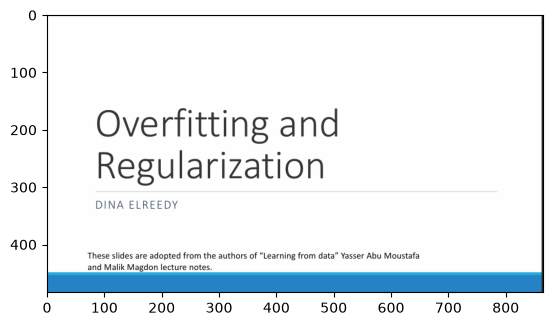

In [5]:
image = cv2.imread("./images/untitled.jpeg")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

In [6]:
net = cv2.dnn.readNet("./models/frozen_east_text_detection.pb")
word_images = extract_word_images(image, net)

In [7]:
img = word_images[0]

In [8]:
mser.setMinArea(100)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
regions, boxes = mser.detectRegions(gray)

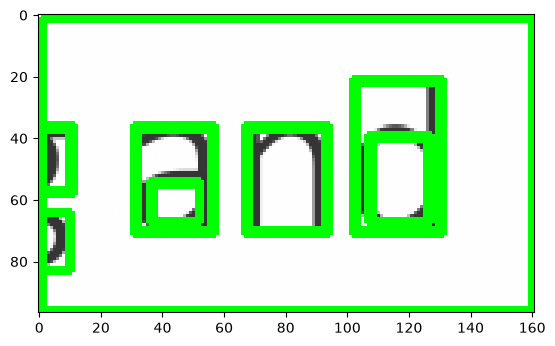

Number of detected regions: 28


In [9]:
unique_boxes = set(tuple(b) for b in boxes)
unique_boxes = [list(b) for b in unique_boxes]
# unique_boxes = merge_boxes(unique_boxes, threshold=0.3)

img_copy = img.copy()
for i in range(len(unique_boxes)):
    x, y, w, h = unique_boxes[i]
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.show()
print(f"Number of detected regions: {len(unique_boxes)}")

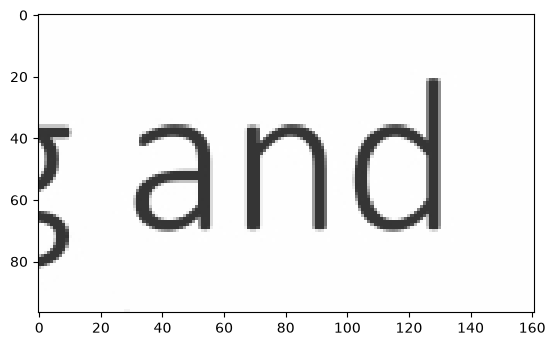

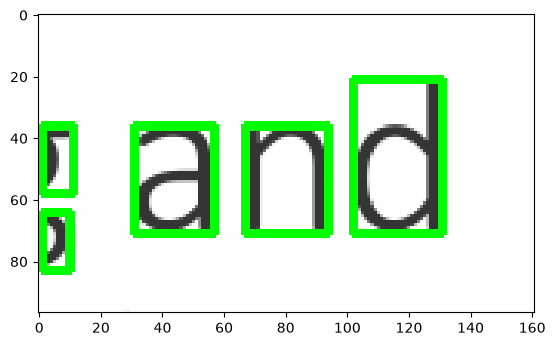

Number of detected regions: 5
Predicted text: and


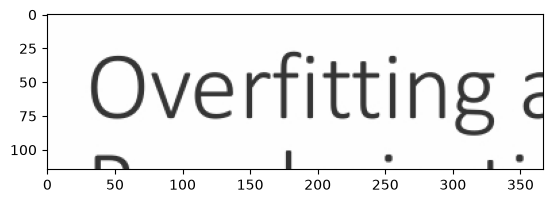

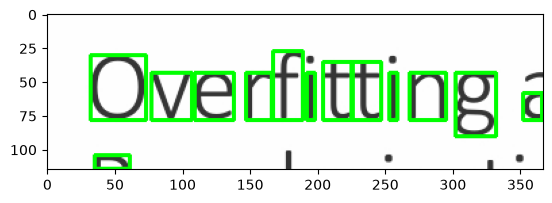

Number of detected regions: 13
Predicted text: ORWerfIttIneC


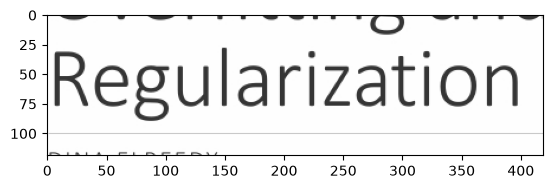

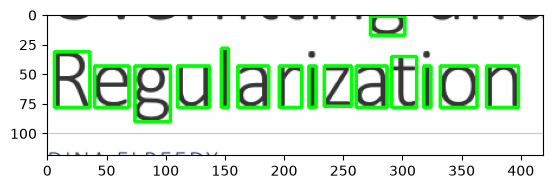

Number of detected regions: 15
Predicted text: ReeUharIZaQtIOn


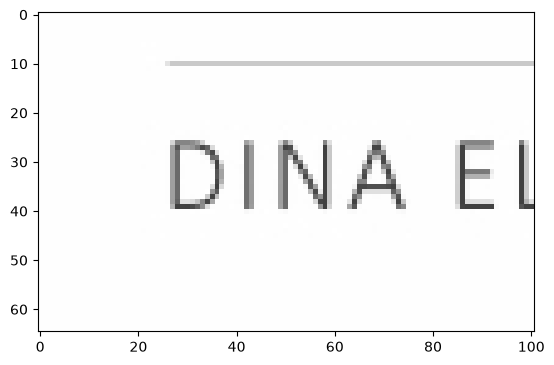

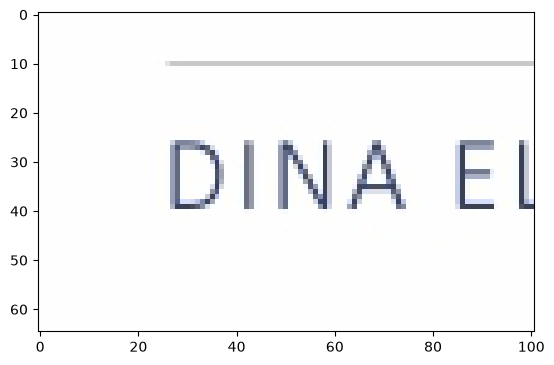

Number of detected regions: 0
Predicted text: ReeUharIZaQtIOn


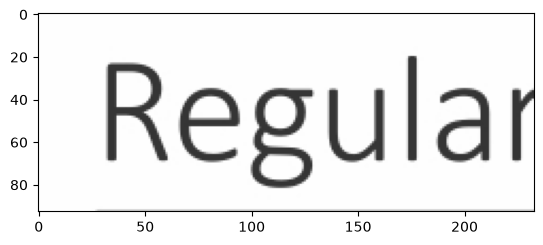

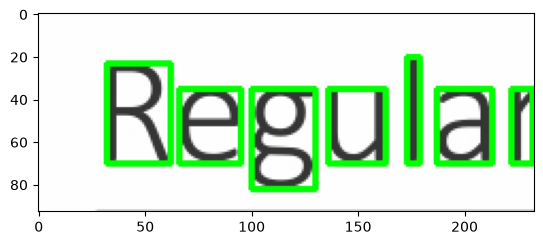

Number of detected regions: 7
Predicted text: ReeUhar


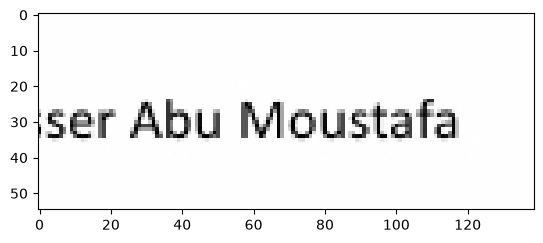

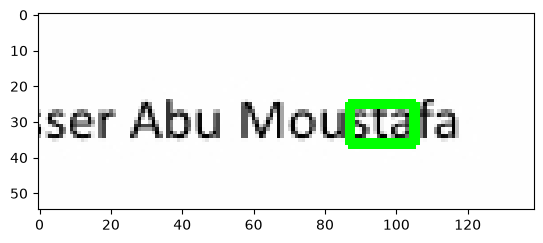

Number of detected regions: 1
Predicted text: M


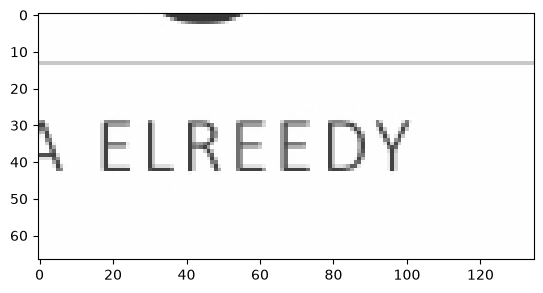

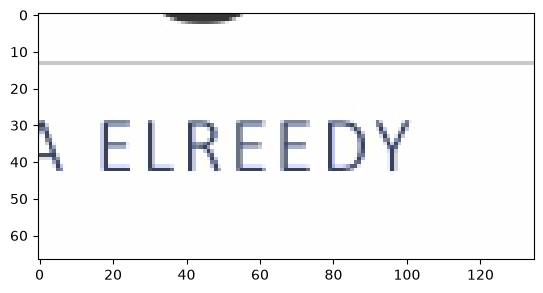

Number of detected regions: 0
Predicted text: M


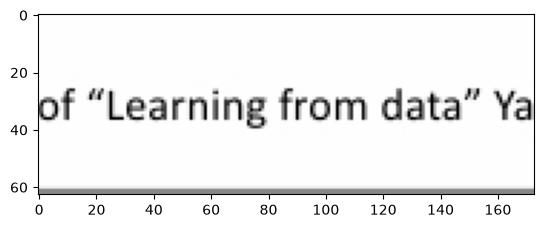

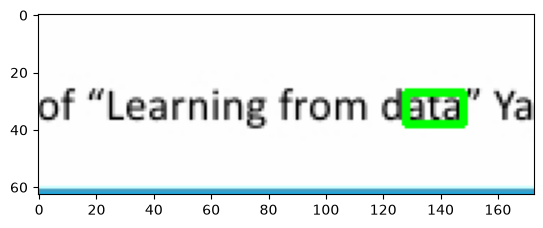

Number of detected regions: 1
Predicted text: M


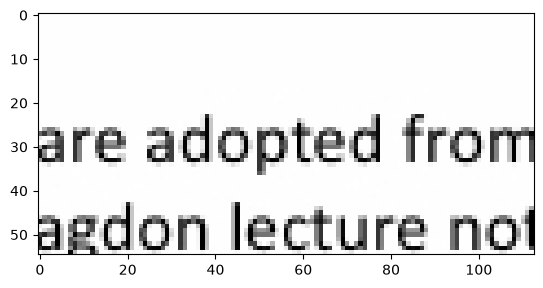

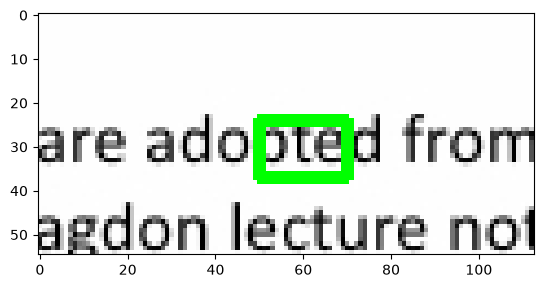

Number of detected regions: 1
Predicted text: M


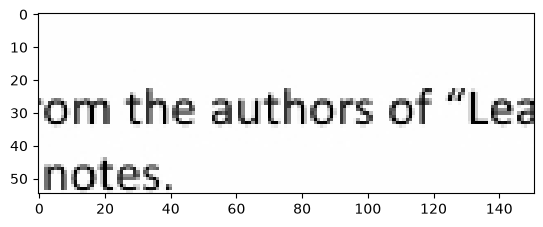

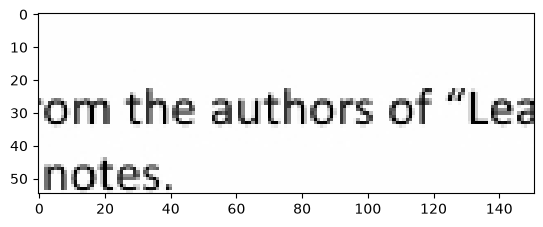

Number of detected regions: 0
Predicted text: M


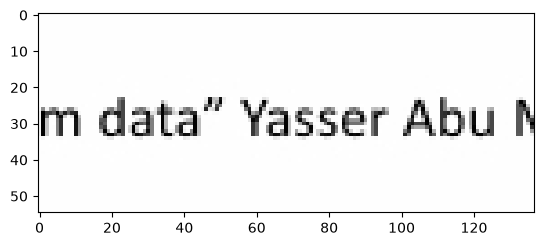

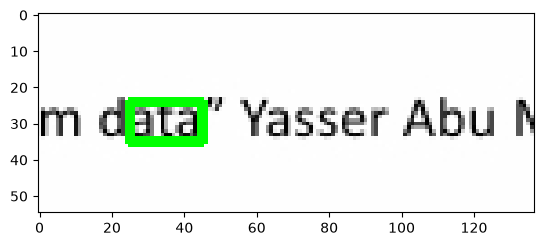

Number of detected regions: 1
Predicted text: M


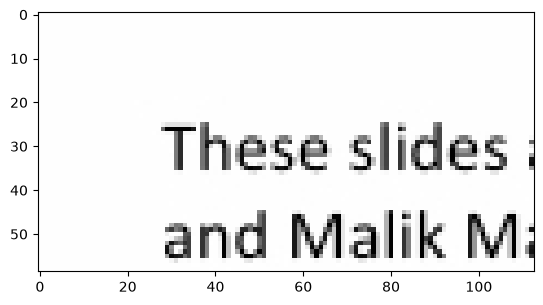

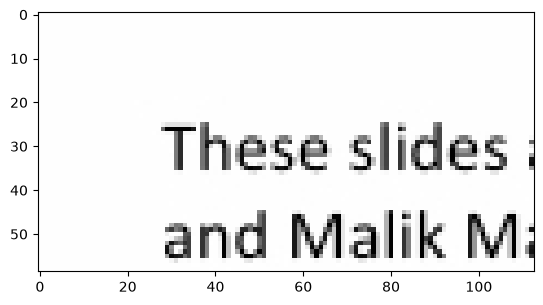

Number of detected regions: 0
Predicted text: M


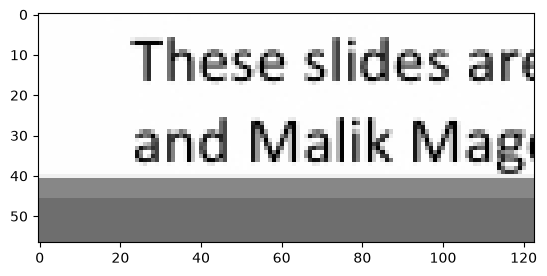

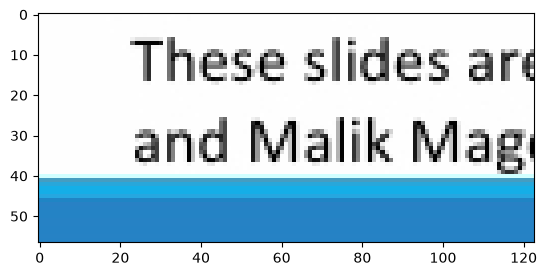

Number of detected regions: 0
Predicted text: M


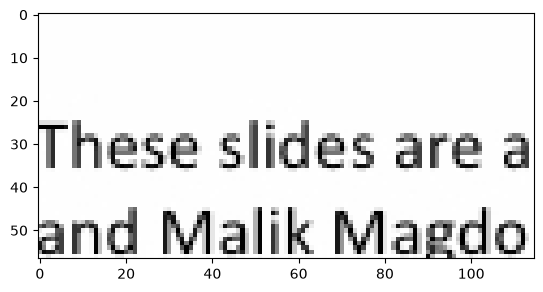

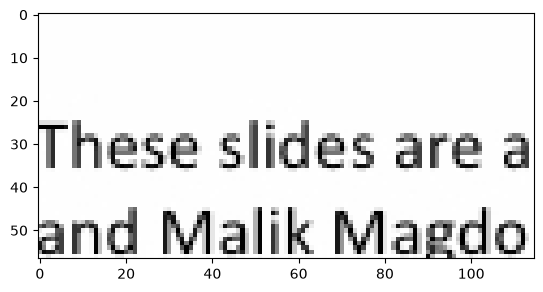

Number of detected regions: 0
Predicted text: M


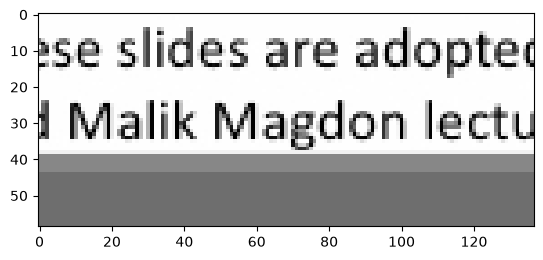

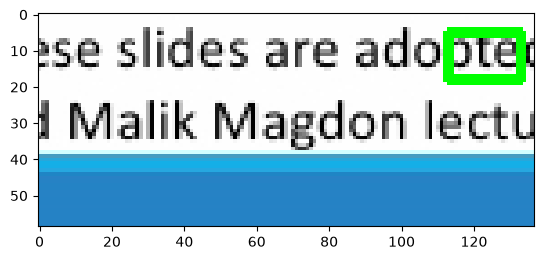

Number of detected regions: 1
Predicted text: M


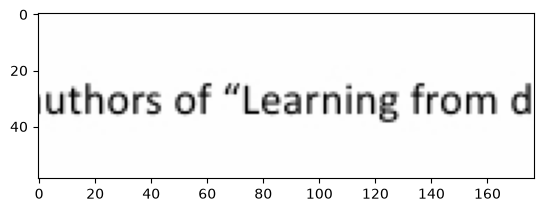

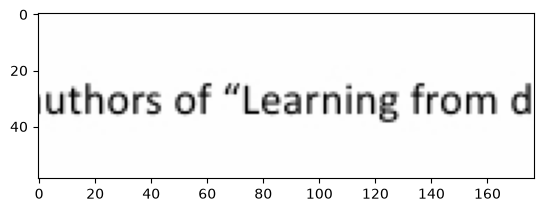

Number of detected regions: 0
Predicted text: M


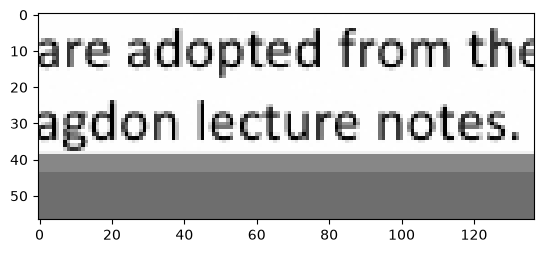

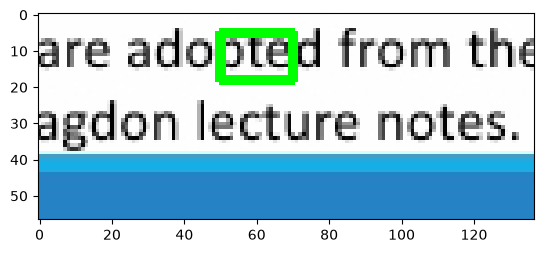

Number of detected regions: 1
Predicted text: M


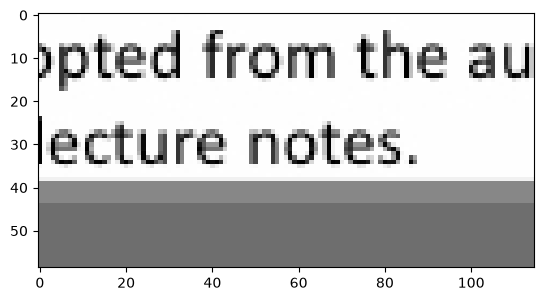

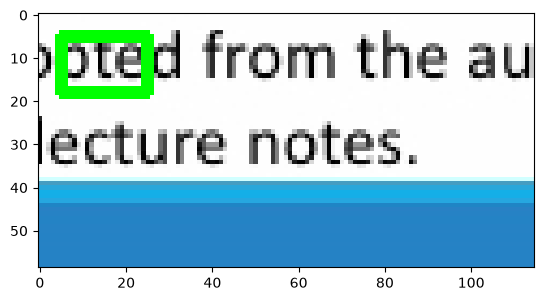

Number of detected regions: 1
Predicted text: M


In [10]:
for img in word_images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
    plt.show()
    regions, boxes = mser.detectRegions(gray)
    unique_boxes = set(tuple(b) for b in boxes)
    unique_boxes = [list(b) for b in unique_boxes]
    unique_boxes = merge_boxes(unique_boxes, threshold=0.3)
    unique_boxes = sort_word_chars(unique_boxes)
    unique_boxes = remove_image_border_box(boxes = unique_boxes, image_shape = img.shape)
    unique_boxes = remove_holes(unique_boxes)
    unique_boxes = remove_large_boxes(unique_boxes, img.shape)
    img_copy = img.copy()
    for i in range(len(unique_boxes)):
        x, y, w, h = unique_boxes[i]
        cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
    plt.show()
    print(f"Number of detected regions: {len(unique_boxes)}")
    text = ""
    for box in unique_boxes:
        x, y, w, h = box
        # print(f"width: {w}, height: {h}")
        # print(f"Box {i}: x={x}, y={y}")
        char_img = gray[y:y+h, x:x+w]
        # print(f"x = {x}, y = {y}")
        
        ## border
        padded_char_img = cv2.copyMakeBorder(char_img, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=255)
        ## blur
        blurred_char_img = cv2.GaussianBlur(padded_char_img, (5, 5), 0)
        ## binarize
        binarized_char_img = cv2.adaptiveThreshold(
            blurred_char_img,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            11,
            2
        )
        
        ## resize
        resized_char_img = cv2.resize(
            binarized_char_img,
            (128, 128),
            interpolation=cv2.INTER_CUBIC
        )
        
        ## erode and dilate
        # eroded = cv2.erode(resized_char_img, np.ones((5, 5), np.uint8), iterations=2)
        dilated = cv2.dilate(resized_char_img, np.ones((3, 3), np.uint8), iterations=1)
        ## normalized
        normalized_char_img = dilated.astype(np.float32) / 255.0
        magnitudes, orientations = calc_gradients(normalized_char_img)
        features = HoG(orientations, magnitudes)
        predicted_label, confidence = predict_char(features, model, le)
        # print("Predicted label for test image:", le.inverse_transform(predicted_label)[0])
        # plt.imshow(normalized_char_img, cmap='gray')
        # plt.show()
        text += le.inverse_transform(predicted_label)[0]
        word_text = TextBlob(text)
    print(f"Predicted text: {word_text.correct()}")
